In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datafusion24-churn/currency_rk.csv
/kaggle/input/datafusion24-churn/report_dates.csv
/kaggle/input/datafusion24-churn/mcc_codes.csv
/kaggle/input/datafusion24-churn/clients.csv
/kaggle/input/datafusion24-churn/train.csv
/kaggle/input/datafusion24-churn/sample_submit_naive.csv
/kaggle/input/datafusion24-churn/transactions.csv/transactions.csv


# Libraries

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style="whitegrid",
    rc={
        "axes.facecolor": "#f7f7f9",      # светло-бело-серый фон
        "figure.facecolor": "#f7f7f9",

        "grid.color": "#e6e6eb",           # очень мягкая сетка
        "grid.linewidth": 0.6,

        "axes.edgecolor": "#dddddd",
        "axes.labelcolor": "#444444",
        "xtick.color": "#555555",
        "ytick.color": "#555555",

        "text.color": "#333333",

        "axes.titleweight": "bold",
        "axes.titlesize": 14,
        "axes.labelsize": 12,
    }
)

# Нежно-розовая палитра
pink_palette = ["#f4b6c2", "#f7c6d0", "#f2a1b3", "#f9d5dc"]
sns.set_palette(pink_palette)


In [3]:
from scipy.stats import fisher_exact
from scipy.stats import chi2_contingency

In [4]:
transactions = pd.read_csv('/kaggle/input/datafusion24-churn/transactions.csv/transactions.csv')
clients = pd.read_csv('/kaggle/input/datafusion24-churn/clients.csv')
currency = pd.read_csv('/kaggle/input/datafusion24-churn/currency_rk.csv')
mcc_codes = pd.read_csv('/kaggle/input/datafusion24-churn/mcc_codes.csv')
reports = pd.read_csv('/kaggle/input/datafusion24-churn/report_dates.csv')
df = pd.read_csv('/kaggle/input/datafusion24-churn/train.csv')

In [5]:
df.head()

,user_id,target,time
0,3,0,77
1,13,0,86
2,37,0,89
3,41,0,57
4,42,0,84


# all datasets heads

In [6]:
transactions.head()

,user_id,mcc_code,currency_rk,transaction_amt,transaction_dttm
0,3,3,1,-183.883957,2022-01-28 12:05:33
1,3,3,1,-3206.437012,2022-01-28 12:52:30
2,3,16,1,-153866.890625,2022-02-16 14:45:56
3,3,56,1,-15144.601562,2022-03-09 19:58:29
4,3,0,1,5297.908691,2022-03-12 18:11:31


In [7]:
clients.head()

,user_id,report,employee_count_nm,bankemplstatus,customer_age
0,3,2,ОТ 101 ДО 500,0,3
1,9,1,БОЛЕЕ 1001,0,3
2,13,6,ОТ 501 ДО 1000,0,2
3,37,5,БОЛЕЕ 1001,0,2
4,41,1,ОТ 101 ДО 500,0,2


In [8]:
currency.head()

,currency_rk,Name
0,48,RUR
1,50,USD
2,60,EUR


In [9]:
mcc_codes.head()

,MCC,Название,Описание
0,742,Ветеринарные услуги,Лицензированные специалисты в основном занимаю...
1,763,Сельскохозяйственные кооперативы,"Ассоциации и кооперативы, которые предоставляю..."
2,780,Услуги садоводства и ландшафтного дизайна,Ландшафтные архитекторы и другие поставщики ус...
3,1520,Генеральные подрядчики – жилое и коммерческое ...,"Генеральные подрядчики, в основном занимающиес..."
4,1711,"Генеральные подрядчики по вентиляции, теплосна...","Специальные торговые подрядчики, которые работ..."


In [10]:
reports.head()

,report,report_dt
0,1,2022-07-31 03:00:00
1,2,2022-08-31 03:00:00
2,3,2022-09-30 03:00:00
3,4,2022-10-31 03:00:00
4,5,2022-11-30 03:00:00


In [11]:
df.head()

,user_id,target,time
0,3,0,77
1,13,0,86
2,37,0,89
3,41,0,57
4,42,0,84


# ignore this part

In [12]:
mcc_codes.head()

,MCC,Название,Описание
0,742,Ветеринарные услуги,Лицензированные специалисты в основном занимаю...
1,763,Сельскохозяйственные кооперативы,"Ассоциации и кооперативы, которые предоставляю..."
2,780,Услуги садоводства и ландшафтного дизайна,Ландшафтные архитекторы и другие поставщики ус...
3,1520,Генеральные подрядчики – жилое и коммерческое ...,"Генеральные подрядчики, в основном занимающиес..."
4,1711,"Генеральные подрядчики по вентиляции, теплосна...","Специальные торговые подрядчики, которые работ..."


In [13]:
mcc_codes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 385 entries, 0 to 384
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   MCC       385 non-null    int64 
 1   Название  385 non-null    object
 2   Описание  290 non-null    object
dtypes: int64(1), object(2)
memory usage: 9.2+ KB


In [14]:
mcc_codes['MCC'].nunique()

385

In [15]:
clients.head()

,user_id,report,employee_count_nm,bankemplstatus,customer_age
0,3,2,ОТ 101 ДО 500,0,3
1,9,1,БОЛЕЕ 1001,0,3
2,13,6,ОТ 501 ДО 1000,0,2
3,37,5,БОЛЕЕ 1001,0,2
4,41,1,ОТ 101 ДО 500,0,2


In [16]:
clients['user_id'].nunique()

96000

In [17]:
clients['bankemplstatus'].value_counts()

bankemplstatus
0    95687
1      313
Name: count, dtype: int64

In [18]:
clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96000 entries, 0 to 95999
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            96000 non-null  int64 
 1   report             96000 non-null  int64 
 2   employee_count_nm  59534 non-null  object
 3   bankemplstatus     96000 non-null  int64 
 4   customer_age       96000 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 3.7+ MB


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   user_id  64000 non-null  int64
 1   target   64000 non-null  int64
 2   time     64000 non-null  int64
dtypes: int64(3)
memory usage: 1.5 MB


In [20]:
data = df.merge(
    clients,
    on='user_id',
    how='inner'
)

In [21]:
data.head()

,user_id,target,time,report,employee_count_nm,bankemplstatus,customer_age
0,3,0,77,2,ОТ 101 ДО 500,0,3
1,13,0,86,6,ОТ 501 ДО 1000,0,2
2,37,0,89,5,БОЛЕЕ 1001,0,2
3,41,0,57,1,ОТ 101 ДО 500,0,2
4,42,0,84,12,ДО 10,0,3


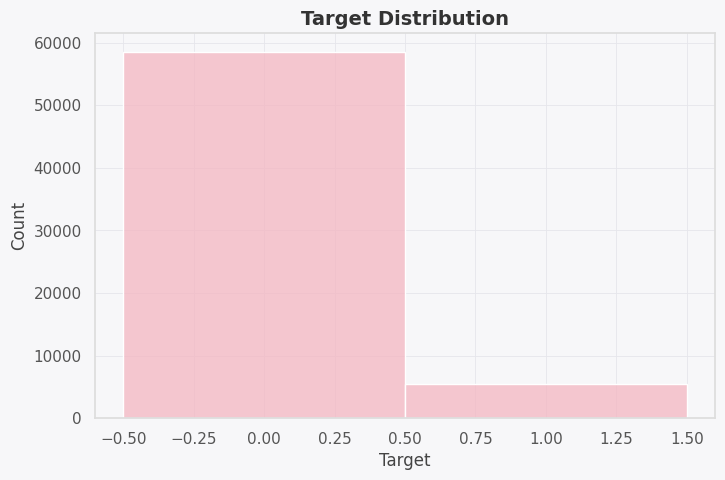

In [22]:
plt.figure(figsize = (8, 5))
sns.histplot(data, x='target', discrete=True)
plt.title('Target Distribution')
plt.xlabel('Target')

plt.savefig('target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [23]:
data['target'].value_counts()

target
0    58583
1     5417
Name: count, dtype: int64

In [24]:
data['target'].value_counts(normalize=True) * 100

target
0    91.535938
1     8.464062
Name: proportion, dtype: float64

With approximately 8.5% of observations belonging to the minority class, the problem is appropriately formulated as a binary classification task with class imbalance, rather than as an anomaly detection problem.

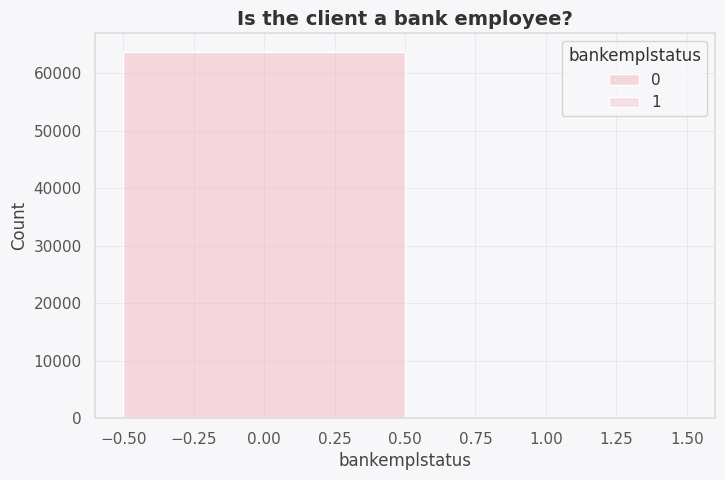

In [25]:
plt.figure(figsize = (8, 5))
sns.histplot(data, x='bankemplstatus', hue='bankemplstatus', discrete=True,  legend=True)
plt.title('Is the client a bank employee?')

plt.savefig('bank_employee.png', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
data['bankemplstatus'].value_counts(normalize=True)*100

bankemplstatus
0    99.678125
1     0.321875
Name: proportion, dtype: float64

In [27]:
data[data['bankemplstatus'] == 1].target.value_counts()

target
0    205
1      1
Name: count, dtype: int64

In [28]:
data[data['bankemplstatus'] == 1].target.value_counts(normalize=True)*100

target
0    99.514563
1     0.485437
Name: proportion, dtype: float64

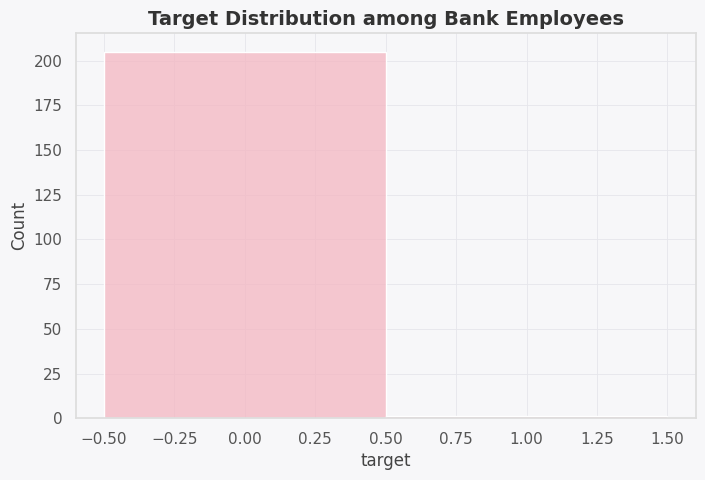

In [29]:
plt.figure(figsize = (8, 5))
sns.histplot(data[data['bankemplstatus'] == 1], x='target', discrete=True)
plt.title('Target Distribution among Bank Employees')

plt.savefig('bank_employee_target.png', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
table = (
    data[data['bankemplstatus'] == 1]
    .target
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

table.columns = ['Target', 'Percentage (%)']
table


,Target,Percentage (%)
0,0,99.51
1,1,0.49


In [31]:
contingency = pd.crosstab(
    data['bankemplstatus'],
    data['target']
)

contingency

target,0,1
bankemplstatus,,
0,58378,5416
1,205,1


In [32]:
oddsratio, p_value = fisher_exact(contingency)

oddsratio, p_value

(np.float64(0.05257952948805707), np.float64(4.6323008218406876e-07))

----

-----

# EDA

## target

## time 

# customer_age

In [33]:
values = data['customer_age'].value_counts(normalize=True).sort_index().values * 100
categories = data['customer_age'].value_counts(normalize=True).sort_index().index

In [34]:
values = data[data['target'] == 1]['customer_age'].value_counts(normalize=True).sort_index().values * 100
categories = data[data['target'] == 1]['customer_age'].value_counts(normalize=True).sort_index().index

In [35]:
churn_share = (
    data[data['target'] == 1]['customer_age']
    .value_counts(normalize=True)
    .sort_index()
)

churn_share

customer_age
0    0.456710
1    0.143807
2    0.155067
3    0.244416
Name: proportion, dtype: float64

In [36]:
contingency = pd.crosstab(data['customer_age'], data['target'])
contingency


target,0,1
customer_age,,
0,13788,2474
1,11987,779
2,13568,840
3,19240,1324


In [37]:
data['is_young'] = (data['customer_age'] == 0).astype(int)

contingency_binary = pd.crosstab(data['is_young'], data['target'])
contingency_binary

target,0,1
is_young,,
0,44795,2943
1,13788,2474


## employee_count_nm  

In [38]:
data['employee_count_missing'] = data['employee_count_nm'].isna().astype(int)

pd.crosstab(data['employee_count_missing'], data['target'], normalize='index')

target,0,1
employee_count_missing,,
0,0.947532,0.052468
1,0.862527,0.137473


In [39]:
values = data['employee_count_nm'].value_counts(dropna=True, normalize=True).sort_index().values * 100
categories = data['employee_count_nm'].value_counts(dropna=True, normalize=True).sort_index().index

In [40]:
data['employee_count_nm'] = data['employee_count_nm'].fillna('Missing')

In [41]:
mapping = {
    # малые
    'ДО 10': 'ДО 10',

    # 11–50 (объединяем всё)
    'ОТ 11 ДО 30': 'ОТ 11 ДО 50',
    'ОТ 31 ДО 50': 'ОТ 11 ДО 50',
    'ОТ 11 ДО 50': 'ОТ 11 ДО 50',

    # 51–100
    'ОТ 51 ДО 100': 'ОТ 51 ДО 100',

    # 101–500
    'ОТ 101 ДО 500': 'ОТ 101 ДО 500',

    # >500 (объединяем всё крупное)
    'ОТ 501 ДО 1000': 'БОЛЕЕ 500',
    'БОЛЕЕ 1001': 'БОЛЕЕ 500',
    'БОЛЕЕ 500': 'БОЛЕЕ 500'
}

In [42]:
data['employee_count_clean'] = (
    data['employee_count_nm']
    .map(mapping)
    .fillna('Missing')
)

In [43]:
order = [
    'Missing',
    'ДО 10',
    'ОТ 11 ДО 50',
    'ОТ 51 ДО 100',
    'ОТ 101 ДО 500',
    'БОЛЕЕ 500'
]

data['employee_count_clean'] = pd.Categorical(
    data['employee_count_clean'],
    categories=order,
    ordered=True
)


##  transactions

In [44]:
tx_target = transactions.merge(data[['user_id', 'target']], on='user_id',how='inner')

In [45]:
currency_target_dist = (tx_target.groupby(['target', 'currency_rk']).size().reset_index(name='count'))


currency_target_dist

,target,currency_rk,count
0,0,0,217549
1,0,1,7875318
2,0,2,861
3,0,3,1069
4,1,0,31384
5,1,1,612265
6,1,2,379
7,1,3,127


In [46]:
transactions.currency_rk.value_counts()

currency_rk
1    12701022
0      370455
3        1795
2        1751
Name: count, dtype: int64

In [47]:
mcc_counts = transactions.groupby('mcc_code').size()

In [48]:
mcc_counts = (
    transactions
    .groupby('mcc_code')
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False))

In [49]:
mcc_counts['share'] = mcc_counts['count'] / mcc_counts['count'].sum()

In [50]:
mcc_counts['cum_share'] = mcc_counts['share'].cumsum()

In [51]:
frequent_mcc = mcc_counts[mcc_counts['cum_share'] <= 0.95].index
transactions['mcc_is_rare'] = (~transactions['mcc_code'].isin(frequent_mcc)).astype(int)

In [52]:
result = (transactions.assign(operation_type=np.where(transactions['transaction_amt'] < 0,'expense', 'income'))
          .groupby(['currency_rk', 'operation_type'])['transaction_amt'].describe())

result

count          mean           std  \
currency_rk operation_type                                           
0           expense           294482.0  -2420.882149   9253.953164   
            income             75973.0   9934.678046  23158.649775   
1           expense         12076289.0  -1776.680280   7835.308157   
            income            624733.0  12797.656349  28427.183670   
2           expense             1605.0  -7253.367452  21977.438345   
            income               146.0  38463.736795  62182.383857   
3           expense             1617.0  -8557.678790  20868.024745   
            income               178.0  32761.054498  49971.615233   

                                      min          25%           50%  \
currency_rk operation_type                                             
0           expense        -213059.359375 -1146.315918   -412.272736   
            income               0.838302   561.180115   2257.084229   
1           expense        -231368.421875  -914.770752   -345.494598   
            income               0.909036   835.461304   3211.826416   
2           expense        -199901.093750 -3136.524170   -798.078430   
            income              36.931274  1863.327545  10576.258301   
3           expense        -217052.796875 -5792.433105  -1604.538208   
            income               6.086504  2412.791077  10807.622070   

                                     75%            max  
currency_rk operation_type                               
0           expense          -161.008526      -0.920293  
            income           8747.108398  327229.937500  
1           expense          -139.530624      -0.864891  
            income          10930.034180  352076.812500  
2           expense          -260.831512      -1.238967  
            income          46676.072266  316142.812500  
3           expense          -521.315674      -1.261406  
            income          38764.103516  246085.859375

In [53]:
user_transactions = (transactions.groupby(['user_id']).agg(main_currency=('currency_rk', lambda x: x.mode().iloc[0]),  main_mcc_code=('mcc_code', lambda x: x.mode().iloc[0])).reset_index())

In [54]:
rare_mcc_flag = (transactions.groupby(['user_id'])['mcc_is_rare'].max().reset_index().rename(columns={'mcc_is_rare': 'has_rare_mcc'}))

In [55]:
user_transactions = user_transactions.merge(rare_mcc_flag, on='user_id', how='left')

In [56]:
number_of_mcc_codes = transactions.groupby(['user_id'])['mcc_code'].nunique().reset_index().rename(columns={'mcc_code': 'number_mcc_codes'})

In [57]:
user_transactions = user_transactions.merge(number_of_mcc_codes, on='user_id', how='left')
user_transactions['number_mcc_codes'].isna().sum()

np.int64(0)

In [58]:
number_of_currency = transactions.groupby(['user_id'])['currency_rk'].nunique().reset_index().rename(columns={'currency_rk': 'unique_currency'})

In [59]:
user_transactions = user_transactions.merge(number_of_currency, on='user_id', how='left')
user_transactions['unique_currency'].isna().sum()

np.int64(0)

In [60]:
user_transactions

,user_id,main_currency,main_mcc_code,has_rare_mcc,number_mcc_codes,unique_currency
0,3,1,0,0,4,1
1,9,1,1,1,22,1
2,13,1,3,0,4,2
3,37,1,2,1,28,1
4,41,1,3,1,5,1
...,...,...,...,...,...,...
95995,562043,1,1,1,12,1
95996,562205,1,11,1,15,1
95997,562312,1,1,1,7,1
95998,562721,1,3,0,11,1


In [61]:
user_money_agg = (
    transactions
    .groupby('user_id')
    .agg(
        total_expense=('transaction_amt', lambda x: x[x < 0].sum()),
        mean_expense=('transaction_amt', lambda x: x[x < 0].mean()),
        median_expense=('transaction_amt', lambda x: x[x < 0].median()),

        total_income=('transaction_amt', lambda x: x[x > 0].sum()),
        mean_income=('transaction_amt', lambda x: x[x > 0].mean()),
        median_income=('transaction_amt', lambda x: x[x > 0].median()),
    )
    .reset_index()
)

user_money_agg.head()

,user_id,total_expense,mean_expense,median_expense,total_income,mean_income,median_income
0,3,-172401.813156,-43100.453289,-9175.519287,186108.229797,26586.889971,5386.999023
1,9,-323434.666813,-3593.718520,-840.509674,0.000000,NaN,NaN
2,13,-253484.063477,-18106.004534,-16423.615234,128766.684326,16095.835541,10789.110840
3,37,-342598.388037,-1094.563540,-236.546936,10738.788574,5369.394287,5369.394287
4,41,-108586.614166,-6786.663385,-6328.293701,0.000000,NaN,NaN


In [62]:
user_money_agg[
    ['total_income', 'mean_income', 'median_income',
     'total_expense', 'mean_expense', 'median_expense']
] = user_money_agg[
    ['total_income', 'mean_income', 'median_income',
     'total_expense', 'mean_expense', 'median_expense']
].fillna(0)

In [63]:
user_transactions = user_transactions.merge(user_money_agg, on='user_id', how='left')

In [64]:
transaction_count = transactions.groupby(['user_id'])['transaction_amt'].count().reset_index().rename(columns={'transaction_amt': 'transaction_count'})

In [65]:
user_transactions = user_transactions.merge(transaction_count, on='user_id', how='left')

In [66]:
transactions.groupby(['user_id'])['transaction_amt'].count().reset_index().rename(columns={'transaction_amt': 'transaction_count'})

,user_id,transaction_count
0,3,11
1,9,90
2,13,22
3,37,315
4,41,16
...,...,...
95995,562043,37
95996,562205,151
95997,562312,56
95998,562721,85


In [67]:
# Берём транзакции в основной MCC
main_mcc_sum = (
    transactions
    .merge(user_transactions[['user_id', 'main_mcc_code']], on='user_id')
    .query('mcc_code == main_mcc_code')
    .groupby('user_id')['transaction_amt']
    .sum()
)

# Берём сумму всех транзакций пользователя
total_sum = (
    transactions.groupby('user_id')['transaction_amt']
    .sum()
)

# Доля по сумме
user_transactions['main_mcc_share_sum'] = (
    main_mcc_sum / total_sum
).fillna(0)


In [68]:
transactions['transaction_dttm'] = pd.to_datetime(transactions['transaction_dttm'])

In [69]:
# Диапазон времени
print(transactions['transaction_dttm'].min(), transactions['transaction_dttm'].max())

# Кол-во транзакций по месяцам
print(transactions['transaction_dttm'].dt.to_period('M').value_counts().sort_index())

# Время между транзакциями для пользователей
tx_diff = transactions.sort_values(['user_id', 'transaction_dttm']).groupby('user_id')['transaction_dttm'].diff()
print(tx_diff.describe())

# День недели / час
print(transactions['transaction_dttm'].dt.dayofweek.value_counts())
print(transactions['transaction_dttm'].dt.hour.value_counts())

2021-10-20 09:00:00 2023-03-20 20:59:58
transaction_dttm
2021-10      76891
2021-11     254007
2021-12     497498
2022-01     581804
2022-02     727372
2022-03     919096
2022-04    1026928
2022-05    1107441
2022-06    1119131
2022-07    1160703
2022-08    1145063
2022-09    1079549
2022-10    1039865
2022-11     816813
2022-12     697310
2023-01     429782
2023-02     272625
2023-03     123145
Freq: M, Name: count, dtype: int64
count                     12979023
mean     1 days 05:37:35.107089724
std      3 days 14:35:50.429415974
min                0 days 00:00:00
25%                0 days 00:53:51
50%                0 days 05:01:54
75%                0 days 23:01:19
max               90 days 22:44:03
Name: transaction_dttm, dtype: object
transaction_dttm
4    2107315
3    1919251
5    1895329
2    1883851
1    1842234
0    1811316
6    1615727
Name: count, dtype: int64
transaction_dttm
15    925334
16    924442
17    897869
14    895569
18    856108
13    838198
19    808383
12    

In [70]:
user_time_features = pd.DataFrame({
    'user_id': transactions['user_id'].unique()
})

In [71]:
# Преобразуем колонку в datetime, если ещё не сделали
transactions['transaction_dttm'] = pd.to_datetime(transactions['transaction_dttm'])

# Первая и последняя транзакция
agg = transactions.groupby('user_id')['transaction_dttm'].agg(
    first_tx='min',
    last_tx='max'
).reset_index()

user_time_features = user_time_features.merge(agg, on='user_id', how='left')

# Спан активности в днях
user_time_features['tx_span_days'] = (
    (user_time_features['last_tx'] - user_time_features['first_tx']).dt.days + 1
)

# Среднее количество транзакций в день
tx_count = transactions.groupby('user_id').size().rename('transaction_count').reset_index()
user_time_features = user_time_features.merge(tx_count, on='user_id', how='left')

user_time_features['tx_per_day'] = user_time_features['transaction_count'] / user_time_features['tx_span_days']


In [72]:
tx_diff = (
    transactions.sort_values(['user_id', 'transaction_dttm'])
    .groupby('user_id')['transaction_dttm']
    .diff()
)

# Медиана в секундах
median_diff = tx_diff.groupby(transactions['user_id']).median().dt.total_seconds().rename('median_tx_delta_sec').reset_index()
user_time_features = user_time_features.merge(median_diff, on='user_id', how='left')


In [73]:
final_df = (data.merge(user_transactions.drop(columns=['transaction_count']), on='user_id', how='left').merge(user_time_features, on='user_id', how='left'))

In [74]:
final_df

,user_id,target,time,report,employee_count_nm,bankemplstatus,customer_age,is_young,employee_count_missing,employee_count_clean,...,total_income,mean_income,median_income,main_mcc_share_sum,first_tx,last_tx,tx_span_days,transaction_count,tx_per_day,median_tx_delta_sec
0,3,0,77,2,ОТ 101 ДО 500,0,3,0,0,ОТ 101 ДО 500,...,186108.229797,26586.889971,5386.999023,NaN,2022-01-28 12:05:33,2022-05-14 20:39:45,107,11,0.102804,524980.0
1,13,0,86,6,ОТ 501 ДО 1000,0,2,0,0,БОЛЕЕ 500,...,128766.684326,16095.835541,10789.110840,NaN,2022-03-23 12:12:40,2022-09-07 20:48:54,169,22,0.130178,586304.0
2,37,0,89,5,БОЛЕЕ 1001,0,2,0,0,БОЛЕЕ 500,...,10738.788574,5369.394287,5369.394287,13.578183,2022-02-19 09:20:06,2022-08-17 09:52:33,180,315,1.750000,17568.0
3,41,0,57,1,ОТ 101 ДО 500,0,2,0,0,ОТ 101 ДО 500,...,0.000000,0.000000,0.000000,NaN,2021-11-16 15:43:21,2022-04-18 20:41:37,154,16,0.103896,186951.5
4,42,0,84,12,ДО 10,0,3,0,0,ДО 10,...,72779.679138,6616.334467,2706.099609,NaN,2022-09-19 12:32:12,2023-03-19 19:49:22,182,59,0.324176,81759.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63995,561824,0,91,12,Missing,0,0,1,1,Missing,...,1939.841522,484.960381,289.726955,2.299547,2022-09-22 09:00:00,2023-03-19 17:10:45,179,148,0.826816,10336.5
63996,562043,0,75,12,Missing,0,2,0,1,Missing,...,0.000000,0.000000,0.000000,NaN,2022-10-06 12:37:37,2023-02-07 06:01:32,124,37,0.298387,74305.0
63997,562312,0,91,12,Missing,0,0,1,1,Missing,...,0.000000,0.000000,0.000000,NaN,2022-09-22 21:08:26,2023-02-27 20:43:58,158,56,0.354430,88993.5
63998,562721,0,29,12,Missing,0,2,0,1,Missing,...,34391.163893,1810.061258,1354.750000,NaN,2022-09-22 05:47:26,2023-03-16 03:00:55,175,85,0.485714,71035.0


In [75]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   user_id                 64000 non-null  int64         
 1   target                  64000 non-null  int64         
 2   time                    64000 non-null  int64         
 3   report                  64000 non-null  int64         
 4   employee_count_nm       64000 non-null  object        
 5   bankemplstatus          64000 non-null  int64         
 6   customer_age            64000 non-null  int64         
 7   is_young                64000 non-null  int64         
 8   employee_count_missing  64000 non-null  int64         
 9   employee_count_clean    64000 non-null  category      
 10  main_currency           64000 non-null  int64         
 11  main_mcc_code           64000 non-null  int64         
 12  has_rare_mcc            64000 non-null  int64 

* user_id   
* target
* time
* report
* employee_count_nm - deleate
* bankemplstatus
* customer_age
* is_young - bool (young or not)
* employee_count_missing - mapping
* employee_count_clean - clean
* main_currency
* main_mcc_code
* has_rare_mcc
* number_mcc_codes
* unique_currency - bool 
* total_expense
* mean_expense - keep one
* median_expense - keep one
* total_income
* mean_income - keep one
* median_income - keep one
* main_mcc_share_sum - delete
* first_tx - delete
* last_tx - delete
* tx_span_days - delete 
* transaction_count
* tx_per_day - ?
* median_tx_delta_sec ? без разницы оставить одно

In [76]:
with pd.option_context('display.max_columns', None):
    display(final_df.head())

,user_id,target,time,report,employee_count_nm,bankemplstatus,customer_age,is_young,employee_count_missing,employee_count_clean,main_currency,main_mcc_code,has_rare_mcc,number_mcc_codes,unique_currency,total_expense,mean_expense,median_expense,total_income,mean_income,median_income,main_mcc_share_sum,first_tx,last_tx,tx_span_days,transaction_count,tx_per_day,median_tx_delta_sec
0,3,0,77,2,ОТ 101 ДО 500,0,3,0,0,ОТ 101 ДО 500,1,0,0,4,1,-172401.813156,-43100.453289,-9175.519287,186108.229797,26586.889971,5386.999023,NaN,2022-01-28 12:05:33,2022-05-14 20:39:45,107,11,0.102804,524980.0
1,13,0,86,6,ОТ 501 ДО 1000,0,2,0,0,БОЛЕЕ 500,1,3,0,4,2,-253484.063477,-18106.004534,-16423.615234,128766.684326,16095.835541,10789.110840,NaN,2022-03-23 12:12:40,2022-09-07 20:48:54,169,22,0.130178,586304.0
2,37,0,89,5,БОЛЕЕ 1001,0,2,0,0,БОЛЕЕ 500,1,2,1,28,1,-342598.388037,-1094.563540,-236.546936,10738.788574,5369.394287,5369.394287,13.578183,2022-02-19 09:20:06,2022-08-17 09:52:33,180,315,1.750000,17568.0
3,41,0,57,1,ОТ 101 ДО 500,0,2,0,0,ОТ 101 ДО 500,1,3,1,5,1,-108586.614166,-6786.663385,-6328.293701,0.000000,0.000000,0.000000,NaN,2021-11-16 15:43:21,2022-04-18 20:41:37,154,16,0.103896,186951.5
4,42,0,84,12,ДО 10,0,3,0,0,ДО 10,1,1,1,20,1,-61350.091923,-1278.126915,-528.145752,72779.679138,6616.334467,2706.099609,NaN,2022-09-19 12:32:12,2023-03-19 19:49:22,182,59,0.324176,81759.0


In [77]:
final_df = final_df[['target', 'bankemplstatus', 'customer_age', 'is_young', 'employee_count_missing', 'employee_count_clean', 'main_currency', 'main_mcc_code', 'has_rare_mcc', 'number_mcc_codes', 'unique_currency', 'total_expense', 'mean_expense', 'median_expense', 'total_income', 'mean_income', 'median_income', 'transaction_count', 'tx_per_day']]

In [78]:
with pd.option_context('display.max_columns', None):
    display(final_df.head())

,target,bankemplstatus,customer_age,is_young,employee_count_missing,employee_count_clean,main_currency,main_mcc_code,has_rare_mcc,number_mcc_codes,unique_currency,total_expense,mean_expense,median_expense,total_income,mean_income,median_income,transaction_count,tx_per_day
0,0,0,3,0,0,ОТ 101 ДО 500,1,0,0,4,1,-172401.813156,-43100.453289,-9175.519287,186108.229797,26586.889971,5386.999023,11,0.102804
1,0,0,2,0,0,БОЛЕЕ 500,1,3,0,4,2,-253484.063477,-18106.004534,-16423.615234,128766.684326,16095.835541,10789.110840,22,0.130178
2,0,0,2,0,0,БОЛЕЕ 500,1,2,1,28,1,-342598.388037,-1094.563540,-236.546936,10738.788574,5369.394287,5369.394287,315,1.750000
3,0,0,2,0,0,ОТ 101 ДО 500,1,3,1,5,1,-108586.614166,-6786.663385,-6328.293701,0.000000,0.000000,0.000000,16,0.103896
4,0,0,3,0,0,ДО 10,1,1,1,20,1,-61350.091923,-1278.126915,-528.145752,72779.679138,6616.334467,2706.099609,59,0.324176


In [79]:
final_df.to_csv('final_df_v2.csv', index=False)